# Clasificación de Piso en el Dataset UJIIndoorLoc usando Redes Neuronales Artificiales (ANN)

---

## Introducción

En este notebook se replica el flujo de análisis implementado previamente para la clasificación del **piso** en un entorno interior utilizando el dataset **UJIIndoorLoc**, pero en esta ocasión aplicando un modelo de **red neuronal artificial** con capas completamente conectadas (Fully Connected – FC).

El conjunto de datos UJIIndoorLoc contiene mediciones de señales WiFi tomadas en diferentes ubicaciones dentro de un edificio, junto con información asociada como coordenadas, piso, usuario y timestamp. Nuestro objetivo sigue siendo predecir el **piso** en el que se encuentra un dispositivo, tratando el problema como una clasificación multiclase (planta baja, primer piso, segundo piso, etc.).

## Objetivos

- **Cargar y explorar** el conjunto de datos UJIIndoorLoc.
- **Preparar** los datos seleccionando las características relevantes y la variable objetivo (`FLOOR`).
- **Dividir** el dataset en entrenamiento y validación (80/20).
- **Construir** una red neuronal totalmente conectada (fully connected ANN) para clasificar el piso.
- **Diseñar y ajustar** la arquitectura de la red (número de capas, unidades por capa, funciones de activación, etc.).
- **Evaluar el desempeño** del modelo en el conjunto de validación mediante métricas como *accuracy*, *precision*, *recall*, y *F1-score*.
- **Comparar los resultados** obtenidos con los modelos clásicos de clasificación entrenados anteriormente.

Este ejercicio permite evaluar la capacidad de generalización de una red neuronal densa sobre datos del mundo real, comparando su desempeño con algoritmos tradicionales y practicando buenas prácticas en diseño, entrenamiento y evaluación de modelos neuronales.

---


## Descripción del Dataset

El dataset utilizado en este análisis es el **UJIIndoorLoc Dataset**, ampliamente utilizado para tareas de localización en interiores a partir de señales WiFi. Está disponible públicamente en la UCI Machine Learning Repository y ha sido recopilado en un entorno real de un edificio universitario.

Cada muestra corresponde a una observación realizada por un dispositivo móvil, donde se registran las intensidades de señal (RSSI) de más de 500 puntos de acceso WiFi disponibles en el entorno. Además, cada fila contiene información contextual como la ubicación real del dispositivo (coordenadas X e Y), el piso, el edificio, el identificador del usuario, y la marca temporal.

El objetivo en esta tarea es predecir el **piso** (`FLOOR`) en el que se encontraba el dispositivo en el momento de la medición, considerando únicamente las características numéricas provenientes de las señales WiFi.

### Estructura del dataset

- **Número de muestras**: ~20,000
- **Número de características**: 520
  - 520 columnas con valores de intensidad de señal WiFi (`WAP001` a `WAP520`)
- **Variable objetivo**: `FLOOR` (variable categórica con múltiples clases, usualmente entre 0 y 4)

### Columnas relevantes

- `WAP001`, `WAP002`, ..., `WAP520`: niveles de señal recibida desde cada punto de acceso WiFi (valores entre -104 y 0, o 100 si no se detectó).
- `FLOOR`: clase objetivo a predecir (nivel del edificio).
- (Otras columnas como `BUILDINGID`, `SPACEID`, `USERID`, `TIMESTAMP`, etc., pueden ser ignoradas o utilizadas en análisis complementarios).

### Contexto del problema

La localización en interiores es un problema complejo en el que tecnologías como el GPS no funcionan adecuadamente. Los sistemas basados en WiFi han demostrado ser una alternativa efectiva para estimar la ubicación de usuarios en edificios. Poder predecir automáticamente el piso en el que se encuentra una persona puede mejorar aplicaciones de navegación en interiores, accesibilidad, gestión de emergencias y servicios personalizados. Este tipo de problemas es típicamente abordado mediante algoritmos de clasificación multiclase.


### Estrategia de evaluación

En este análisis seguiremos una metodología rigurosa para garantizar la validez de los resultados:

1. **Dataset de entrenamiento**: Se utilizará exclusivamente para el desarrollo, entrenamiento y optimización de hiperparámetros de todos los modelos. Este conjunto será dividido internamente en subconjuntos de entrenamiento y validación (80/20) para la selección de hiperparámetros mediante validación cruzada.

2. **Dataset de prueba**: Se reservará únicamente para la **evaluación final** de los modelos ya optimizados. Este conjunto **no debe ser utilizado** durante el proceso de selección de hiperparámetros, ajuste de modelos o toma de decisiones sobre la arquitectura, ya que esto introduciría sesgo y comprometería la capacidad de generalización estimada.

3. **Validación cruzada**: Para la optimización de hiperparámetros se empleará validación cruzada 5-fold sobre el conjunto de entrenamiento, lo que permitirá una estimación robusta del rendimiento sin contaminar los datos de prueba.

Esta separación estricta entre datos de desarrollo y evaluación final es fundamental para obtener una estimación realista del rendimiento que los modelos tendrían en un escenario de producción con datos completamente nuevos.

---


In [7]:
# === Celda 0: Setup / Configuración base ===
from pathlib import Path
import numpy as np
import pandas as pd

# Semilla global (reproducibilidad)
SEED = 42
rng = np.random.default_rng(SEED)

# Rutas (ajustadas a tu estructura)
DATA_DIR   = Path(r"C:\IA_RigobertoZelayandia\CLase-IA\PROYECTO FINAL\dataset")
TRAIN_PATH = DATA_DIR / "trainingData.csv"
VALID_PATH = DATA_DIR / "validationData.csv"

print("TRAIN_PATH:", TRAIN_PATH)
print("VALID_PATH:", VALID_PATH)
print("Existencia -> train:", TRAIN_PATH.exists(), "| valid:", VALID_PATH.exists())


TRAIN_PATH: C:\IA_RigobertoZelayandia\CLase-IA\PROYECTO FINAL\dataset\trainingData.csv
VALID_PATH: C:\IA_RigobertoZelayandia\CLase-IA\PROYECTO FINAL\dataset\validationData.csv
Existencia -> train: True | valid: True


## Paso 1: Cargar y explorar el dataset

**Instrucciones:**
- Descarga el dataset **UJIIndoorLoc** desde la UCI Machine Learning Repository o utiliza la versión proporcionada en el repositorio del curso (por ejemplo: `datasets\UJIIndoorLoc\trainingData.csv`).
- Carga el dataset utilizando `pandas`.
- Muestra las primeras filas del dataset utilizando `df.head()`.
- Imprime el número total de muestras (filas) y características (columnas).
- Verifica cuántas clases distintas hay en la variable objetivo `FLOOR` y cuántas muestras tiene cada clase (`df['FLOOR'].value_counts()`).


In [8]:
# === PASO 1: Cargar y explorar el dataset (solo TRAIN) ===
import pandas as pd

# 1) Carga (solo datos de entrenamiento / desarrollo)
df = pd.read_csv(TRAIN_PATH)

# 2) Vista rápida
display(df.head())

# 3) Tamaños
n_filas, n_cols = df.shape
print(f"Shape (filas, columnas): {df.shape}")

# 4) Info de columnas y tipos (opcional, pero útil)
print("\nTipos de datos (primeras columnas):")
print(df.dtypes.head(10))

# 5) Clases de la variable objetivo FLOOR
if "FLOOR" not in df.columns:
    raise ValueError("No se encontró la columna 'FLOOR' en el dataset de entrenamiento.")

vc = df["FLOOR"].value_counts().sort_index()
print("\nClases distintas en FLOOR:", sorted(df["FLOOR"].unique()))
print("\nConteo por clase (FLOOR):")
print(vc)

print("\nDistribución porcentual por clase (FLOOR):")
print((vc / vc.sum() * 100).round(2).astype(str) + "%")

# --- Nota importante (recordatorio) ---
print("\n[AVISO] El archivo 'validationData.csv' se usará SOLO para la evaluación final.\n"
      "No se usará en ajuste de hiperparámetros ni decisiones de modelo.")


,WAP001,WAP002,WAP003,WAP004,WAP005,WAP006,WAP007,WAP008,WAP009,WAP010,...,WAP520,LONGITUDE,LATITUDE,FLOOR,BUILDINGID,SPACEID,RELATIVEPOSITION,USERID,PHONEID,TIMESTAMP
0,100,100,100,100,100,100,100,100,100,100,...,100,-7541.2643,4.864921e+06,2,1,106,2,2,23,1371713733
1,100,100,100,100,100,100,100,100,100,100,...,100,-7536.6212,4.864934e+06,2,1,106,2,2,23,1371713691
2,100,100,100,100,100,100,100,-97,100,100,...,100,-7519.1524,4.864950e+06,2,1,103,2,2,23,1371714095
3,100,100,100,100,100,100,100,100,100,100,...,100,-7524.5704,4.864934e+06,2,1,102,2,2,23,1371713807
4,100,100,100,100,100,100,100,100,100,100,...,100,-7632.1436,4.864982e+06,0,0,122,2,11,13,1369909710


Shape (filas, columnas): (19937, 529)

Tipos de datos (primeras columnas):
WAP001    int64
WAP002    int64
WAP003    int64
WAP004    int64
WAP005    int64
WAP006    int64
WAP007    int64
WAP008    int64
WAP009    int64
WAP010    int64
dtype: object

Clases distintas en FLOOR: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Conteo por clase (FLOOR):
FLOOR
0    4369
1    5002
2    4416
3    5048
4    1102
Name: count, dtype: int64

Distribución porcentual por clase (FLOOR):
FLOOR
0    21.91%
1    25.09%
2    22.15%
3    25.32%
4     5.53%
Name: count, dtype: object

[AVISO] El archivo 'validationData.csv' se usará SOLO para la evaluación final.
No se usará en ajuste de hiperparámetros ni decisiones de modelo.


---

## Paso 2: Preparar los datos

**Instrucciones:**

- Elimina las columnas que no son relevantes para la tarea de clasificación del piso:
  - `LONGITUDE`, `LATITUDE`, `SPACEID`, `RELATIVEPOSITION`, `USERID`, `PHONEID`, `TIMESTAMP`
- Conserva únicamente:
  - Las columnas `WAP001` a `WAP520` como características (RSSI de puntos de acceso WiFi).
  - La columna `FLOOR` como variable objetivo.
- Verifica si existen valores atípicos o valores inválidos en las señales WiFi (por ejemplo: valores constantes como 100 o -110 que suelen indicar ausencia de señal).
- Separa el conjunto de datos en:
  - `X`: matriz de características (todas las columnas `WAP`)
  - `y`: vector objetivo (`FLOOR`)


In [9]:
import numpy as np
import pandas as pd
import re

# 0) Comprobar que 'df' existe (del Paso 1, TRAIN cargado)
assert 'df' in globals(), "Primero ejecuta el Paso 1 para cargar el dataset de entrenamiento en 'df'."

# 1) Columnas no relevantes (si alguna no existe, se ignora sin error)
DROP_COLS = ['LONGITUDE','LATITUDE','SPACEID','RELATIVEPOSITION','USERID','PHONEID','TIMESTAMP']
df2 = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')

# 2) Detectar columnas WAP: nombres tipo WAP001..WAP520
WAP_COLS = sorted([c for c in df2.columns if re.fullmatch(r"WAP\d{3}", c)])
if not WAP_COLS:
    raise ValueError("No se encontraron columnas WAP (patrón WAP###) en el dataset.")

# 3) Asegurar que FLOOR existe y es entero
if "FLOOR" not in df2.columns:
    raise ValueError("No se encontró la columna 'FLOOR' en el dataset de entrenamiento.")
y = df2["FLOOR"].astype(int)

# 4) Asegurar numéricos en WAPs (si hubiera strings, se fuerzan; valores no convertibles -> NaN)
df2[WAP_COLS] = df2[WAP_COLS].apply(pd.to_numeric, errors="coerce")

# 5) Separar matriz de características X (solo WAPs)
X = df2[WAP_COLS].copy()

print(f"Total de WAPs seleccionadas: {len(WAP_COLS)}")
print(f"Shape X: {X.shape} | Shape y: {y.shape}")

# 6) Revisión de valores típicos de ausencia/ruido en señal
total_vals = X.size
cnt_100   = np.sum(X.values == 100)     # convención muy usada para "sin señal"
cnt_m110  = np.sum(X.values == -110)    # otra convención posible
cnt_nan   = np.isnan(X.values).sum()

print("\n--- Chequeo de valores 'inválidos' o marcadores de ausencia de señal ---")
print(f"Valores 100   : {cnt_100:,}  ({cnt_100/total_vals:.2%})")
print(f"Valores -110  : {cnt_m110:,}  ({cnt_m110/total_vals:.2%})")
print(f"Valores NaN   : {cnt_nan:,}   ({cnt_nan/total_vals:.2%})")

# 7) Top 10 WAP con mayor proporción de (100, -110 o NaN)
ratio_invalid = ((X == 100) | (X == -110) | X.isna()).mean()
top_bad = ratio_invalid.sort_values(ascending=False).head(10).to_frame("ratio_invalid")
print("\nTop 10 WAP con mayor proporción de valores inválidos:")
display(top_bad.style.format({"ratio_invalid": "{:.2%}"}))

# 8) Guardar copias para siguientes pasos
X_train_raw = X.copy()   # versión "cruda" para paso 3 (mapeo 100 -> -100)
y_train     = y.copy()




Total de WAPs seleccionadas: 520
Shape X: (19937, 520) | Shape y: (19937,)

--- Chequeo de valores 'inválidos' o marcadores de ausencia de señal ---
Valores 100   : 10,008,477  (96.54%)
Valores -110  : 0  (0.00%)
Valores NaN   : 0   (0.00%)

Top 10 WAP con mayor proporción de valores inválidos:


,ratio_invalid
WAP520,100.00%
WAP497,100.00%
WAP491,100.00%
WAP487,100.00%
WAP488,100.00%
WAP485,100.00%
WAP482,100.00%
WAP247,100.00%
WAP451,100.00%
WAP458,100.00%


--- 

## Paso 3: Preprocesamiento de las señales WiFi

**Contexto:**

Las columnas `WAP001` a `WAP520` representan la intensidad de la señal (RSSI) recibida desde distintos puntos de acceso WiFi. Los valores típicos de RSSI están en una escala negativa, donde:

- Valores cercanos a **0 dBm** indican señal fuerte.
- Valores cercanos a **-100 dBm** indican señal débil o casi ausente.
- Un valor de **100** en este dataset representa una señal **no detectada**, es decir, el punto de acceso no fue visto por el dispositivo en ese instante.

**Instrucciones:**

- Para facilitar el procesamiento y tratar la ausencia de señal de forma coherente, se recomienda mapear todos los valores **100** a **-100**, que semánticamente representa *ausencia de señal detectable*.
- Esto unifica el rango de valores y evita que 100 (un valor artificial) afecte negativamente la escala de los algoritmos.

**Pasos sugeridos:**

- Reemplaza todos los valores `100` por `-100` en las columnas `WAP001` a `WAP520`:
  ```python
  X[X == 100] = -100


In [10]:
# === PASO 3: Preprocesamiento de señales (solo TRAIN) ===

import numpy as np
import pandas as pd

def preprocess_wifi(X, fill_missing_with=-110):
    Xp = X.copy()
    # 1) Mapear 100 -> -100
    Xp = Xp.replace(100, -100)
    # 2) (Opcional) Imputar NaN si hubiesen
    if fill_missing_with is not None:
        Xp = Xp.fillna(fill_missing_with)
    # 3) (Opcional) Limitar a un rango típico [-110, 0] para evitar outliers raros
    Xp = Xp.clip(lower=-110, upper=0)
    return Xp

# Comprobación de que venimos del Paso 2
assert 'X_train_raw' in globals() and 'y_train' in globals(), \
       "Primero ejecuta el Paso 2 (X_train_raw, y_train)."

# --- conteo antes ---
total_vals = X_train_raw.size
cnt_100   = np.sum(X_train_raw.values == 100)
cnt_m110  = np.sum(X_train_raw.values == -110)
cnt_nan   = np.isnan(X_train_raw.values).sum()
print("[ANTES] 100:", cnt_100, "| -110:", cnt_m110, "| NaN:", cnt_nan, f"| total={total_vals}")

# Procesar
X_train = preprocess_wifi(X_train_raw, fill_missing_with=-110)

# --- conteo después ---
total_vals2 = X_train.size
cnt_100_2   = np.sum(X_train.values == 100)
cnt_m100_2  = np.sum(X_train.values == -100)
cnt_m110_2  = np.sum(X_train.values == -110)
cnt_nan_2   = np.isnan(X_train.values).sum()

print("[DESPUÉS] 100:", cnt_100_2,
      "| -100:", cnt_m100_2,
      "| -110:", cnt_m110_2,
      "| NaN:", cnt_nan_2,
      f"| total={total_vals2}")



[ANTES] 100: 10008477 | -110: 0 | NaN: 0 | total=10367240
[DESPUÉS] 100: 0 | -100: 10008716 | -110: 0 | NaN: 0 | total=10367240


---

## Paso 4: Preparación del dataset

**Objetivo:**

Diseñar una función que cargue el dataset **UJIIndoorLoc**, realice limpieza básica si es necesario, normalice las variables predictoras, y divida los datos en tres subconjuntos de forma estratificada para su uso en redes neuronales.

**Esquema de partición:**

1. **20% del dataset se reserva como conjunto de testeo final.**
2. **El 80% restante se subdivide en:**
   - **80% para entrenamiento** → equivale al 64% del total.
   - **20% para validación** → equivale al 16% del total.

  En este caso, ya existe un conjunto de testeo definido por separado. Por lo tanto, la función solo debe dividir el dataset de entrenamiento original en dos subconjuntos estratificados:

  - **80% para entrenamiento**
  - **20% para validación**

**Requisitos de la función:**

- La función debe realizar las siguientes tareas:
  1. Cargar el archivo `.csv` del dataset.
  2. Seleccionar las columnas de entrada (features) y la variable objetivo (`FLOOR`).
  3. Aplicar normalización a las variables predictoras utilizando `MinMaxScaler` para que todos los valores queden entre 0 y 1.
  4. Realizar las divisiones del conjunto de datos en el orden indicado, asegurando estratificación según la variable objetivo.
  
- La función debe recibir como parámetros:
  - La ruta al archivo `.csv` del dataset.
  - El nombre de la columna objetivo (por ejemplo, `FLOOR`).
  - Un parámetro `random_state` para asegurar reproducibilidad de las divisiones.

- La función debe retornar:
  - `X_train`, `X_val`, `X_test`: subconjuntos de características normalizadas.
  - `y_train`, `y_val`, `y_test`: subconjuntos de etiquetas, codificadas si es necesario para clasificación multiclase.

**Nota:** Esta función es fundamental para garantizar un flujo de entrenamiento robusto y reproducible en redes neuronales.


In [11]:
# === PASO 4: Entrenamiento + Optimización (solo con TRAIN) ===
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Comprobación de que venimos del paso 3
assert 'X_train' in globals() and 'y_train' in globals(), \
       "Primero ejecuta los pasos 1–3 para tener X_train e y_train."

SEED = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = []
best_models = {}

def run_grid(name, pipe, param_grid, scoring='accuracy', cv=cv):
    """Helper: entrena GridSearchCV, guarda mejor CV y el mejor estimador."""
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=0
    )
    gs.fit(X_train, y_train)
    print(f"{name:12s} | best_cv={gs.best_score_:.4f} | params={gs.best_params_}")
    results.append({
        "modelo": name,
        "best_cv": gs.best_score_,
        "best_params": gs.best_params_,
        "best_estimator": gs.best_estimator_
    })
    best_models[name] = gs.best_estimator_
    return gs

# ---------- KNN ----------
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier())
])
param_grid = {
    "clf__n_neighbors": [3, 5, 7, 9],
    "clf__weights": ["uniform", "distance"],
    "clf__p": [1, 2],  # Manhattan / Euclídea
}
gs_knn = run_grid("KNN", pipe, param_grid)

# ---------- Gaussian Naive Bayes ----------
pipe = Pipeline([
    ("clf", GaussianNB())
])
param_grid = {
    "clf__var_smoothing": [1e-9, 1e-8, 1e-7]
}
gs_gnb = run_grid("GaussianNB", pipe, param_grid)

# ---------- Regresión Logística ----------
# Nota: lbfgs funciona bien con multiclase; escalado en pipeline.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])
param_grid = {
    "clf__C": [0.1, 1.0, 10.0],
    "clf__solver": ["lbfgs"],  # estable para multiclase
}
gs_lr = run_grid("LogReg", pipe, param_grid)

# ---------- Árbol de Decisión ----------
pipe = Pipeline([
    ("clf", DecisionTreeClassifier(random_state=SEED))
])
param_grid = {
    "clf__max_depth": [10, 20, 30, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 5],
}
gs_dt = run_grid("DecisionTree", pipe, param_grid)

# ---------- SVM (RBF) ----------
# SVM suele ser costoso; grid compacto + escalado.
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", cache_size=1000, random_state=SEED))
])
param_grid = {
    "clf__C": [1, 10, 100],
    "clf__gamma": ["scale", 0.01, 0.001],
}
gs_svm = run_grid("SVM (rbf)", pipe, param_grid)

# ---------- Random Forest ----------
pipe = Pipeline([
    ("clf", RandomForestClassifier(
        random_state=SEED, n_jobs=-1
    ))
])
param_grid = {
    "clf__n_estimators": [200, 400],
    "clf__max_depth": [None, 20, 40],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2],
}
gs_rf = run_grid("RandomForest", pipe, param_grid)

# ---------- Resumen ordenado por mejor CV ----------
summary = (
    pd.DataFrame([{k: v for k, v in r.items() if k != "best_estimator"} for r in results])
    .sort_values("best_cv", ascending=False)
    .reset_index(drop=True)
)
display(summary)

print("\n[OK] Paso 4 completado. 'best_models' contiene los mejores estimadores por modelo.")


KNN          | best_cv=0.9954 | params={'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance'}
GaussianNB   | best_cv=0.5830 | params={'clf__var_smoothing': 1e-07}
LogReg       | best_cv=0.9933 | params={'clf__C': 1.0, 'clf__solver': 'lbfgs'}
DecisionTree | best_cv=0.9720 | params={'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}
SVM (rbf)    | best_cv=0.9940 | params={'clf__C': 10, 'clf__gamma': 0.001}
RandomForest | best_cv=0.9966 | params={'clf__max_depth': 40, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 400}


,modelo,best_cv,best_params
0,RandomForest,0.996589,"{'clf__max_depth': 40, 'clf__min_samples_leaf'..."
1,KNN,0.995436,"{'clf__n_neighbors': 3, 'clf__p': 1, 'clf__wei..."
2,SVM (rbf),0.993981,"{'clf__C': 10, 'clf__gamma': 0.001}"
3,LogReg,0.993329,"{'clf__C': 1.0, 'clf__solver': 'lbfgs'}"
4,DecisionTree,0.972012,"{'clf__max_depth': None, 'clf__min_samples_lea..."
5,GaussianNB,0.582986,{'clf__var_smoothing': 1e-07}



[OK] Paso 4 completado. 'best_models' contiene los mejores estimadores por modelo.


---
## Paso 5: Entrenamiento de redes neuronales artificiales (ANN)

**Objetivo:**

Entrenar y comparar el rendimiento de diferentes arquitecturas de redes neuronales totalmente conectadas (**Fully Connected ANN**) utilizando **PyTorch** para predecir el piso (`FLOOR`) en el dataset UJIIndoorLoc. El objetivo es observar el impacto de la profundidad y la expansión/compresión de capas sobre el rendimiento del modelo.

**Entorno y configuración:**

- **Framework:** PyTorch
- **Función de pérdida:** `nn.CrossEntropyLoss()`  
  > Esta función es equivalente a `sparse_categorical_crossentropy`, por lo que **no es necesario one-hot encoding** en las etiquetas.
- **Optimizador:** `torch.optim.Adam`
- **Activación:** `ReLU` en todas las capas ocultas
- **Salida:** `Softmax` (implícito en `CrossEntropyLoss`)
- **Épocas:** 20
- **Batch size: 32**
- **Sin Dropout ni BatchNormalization**


### Arquitecturas a evaluar

1. **Arquitectura 1: Compacta**
   ```text
   Input (520)
   → Linear(128) + ReLU
   → Linear(4)
   ```

2. **Arquitectura 2: Dos capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(4)
   ```

3. **Arquitectura 3: Tres capas ocultas**
   ```text
   Input (520)
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64) + ReLU
   → Linear(4)
   ```

4. **Arquitectura 4: Pirámide profunda**
   ```text
   Input (520)
   → Linear(512) + ReLU
   → Linear(256) + ReLU
   → Linear(128) + ReLU
   → Linear(64)  + ReLU
   → Linear(4)
   ```

5. **Arquitectura 5: Expansiva y luego compresiva**
   ```text
   Input (520)
   → Linear(1024) + ReLU
   → Linear(512)  + ReLU
   → Linear(256)  + ReLU
   → Linear(128)  + ReLU
   → Linear(64)   + ReLU
   → Linear(4)
   ```


### Instrucciones

- Implementa cada arquitectura como una subclase de `nn.Module` en PyTorch.
- Entrena durante **20 épocas**, utilizando el conjunto de entrenamiento (`X_train`, `y_train`) y validación (`X_val`, `y_val`).
- Registra la **pérdida de entrenamiento y validación** por época en un gráfico.
- Grafica la evolución de la pérdida para analizar tendencias de aprendizaje, sobreajuste o subajuste.
- Evalúa el modelo final con el conjunto de test (`X_test`, `y_test`) y reporta:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**

In [14]:
# === Bootstrap PASOS 1–4 en 1 celda: deja X_train, y_train, X_test, y_test listos ===
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Ajusta la ruta si tu notebook no está en la carpeta del proyecto
TRAIN_CSV = r"dataset/trainingData.csv"
TEST_CSV  = r"dataset/validationData.csv"

# 1) Cargar
df_tr = pd.read_csv(TRAIN_CSV)
df_te = pd.read_csv(TEST_CSV)

# 2) Conservar solo WAP001..WAP520 + FLOOR
label = "FLOOR"
wap_cols = [c for c in df_tr.columns if c.upper().startswith("WAP")]
df_tr = df_tr[wap_cols + [label]]
df_te = df_te[wap_cols + [label]]

# 3) Preprocesamiento de señales: 100 (no detectado) -> -100
for df in (df_tr, df_te):
    df[wap_cols] = df[wap_cols].replace(100, -100)

# 4) Separar X / y
X_train_raw = df_tr[wap_cols].values.astype(np.float32)
y_train     = df_tr[label].values.astype(np.int64)
X_test_raw  = df_te[wap_cols].values.astype(np.float32)
y_test      = df_te[label].values.astype(np.int64)

# 5) Escalado (fit SOLO con train)
scaler  = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print("Listo ✅")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Clases en train:", np.unique(y_train))


Listo ✅
X_train: (19937, 520) y_train: (19937,)
X_test : (1111, 520) y_test : (1111,)
Clases en train: [0 1 2 3 4]


Setup + split (train/val) + DataLoaders

In [15]:
# === Paso 5.1 | Setup, split y dataloaders ===
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

assert 'X_train' in globals() and 'y_train' in globals(), "Falta X_train / y_train (ejecuta antes los pasos 1–4)"
assert 'X_test'  in globals() and 'y_test'  in globals(), "Falta X_test / y_test (ejecuta antes los pasos 1–4)"

# split 80/20 para validación (SOLO con el conjunto de entrenamiento)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

# shapes dinámicos
N_INPUT   = X_tr.shape[1]
N_CLASSES = int(np.unique(y_train).shape[0])

# tensores
X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_te_t  = torch.tensor(X_test, dtype=torch.float32)
y_te_t  = torch.tensor(y_test, dtype=torch.long)

BATCH_SIZE = 32
train_loader = DataLoader(TensorDataset(X_tr_t,  y_tr_t),  batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te_t,  y_te_t),  batch_size=BATCH_SIZE, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [16]:
# === Paso 5.2 | Modelos ===
class ANN1_Compacta(nn.Module):
    # Input -> 128 -> 4
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 128), nn.ReLU(),
            nn.Linear(128, n_out)
        )
    def forward(self, x): return self.net(x)

class ANN2_DosCapas(nn.Module):
    # Input -> 256 -> 128 -> 4
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, n_out)
        )
    def forward(self, x): return self.net(x)

class ANN3_TresCapas(nn.Module):
    # Input -> 256 -> 128 -> 64 -> 4
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128,  64), nn.ReLU(),
            nn.Linear(64, n_out)
        )
    def forward(self, x): return self.net(x)

class ANN4_Piramide(nn.Module):
    # Input -> 512 -> 256 -> 128 -> 64 -> 4
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128,  64), nn.ReLU(),
            nn.Linear(64, n_out)
        )
    def forward(self, x): return self.net(x)

class ANN5_ExpComp(nn.Module):
    # Input -> 1024 -> 512 -> 256 -> 128 -> 64 -> 4
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512,  256), nn.ReLU(),
            nn.Linear(256,  128), nn.ReLU(),
            nn.Linear(128,  64), nn.ReLU(),
            nn.Linear(64, n_out)
        )
    def forward(self, x): return self.net(x)


In [17]:
# === Paso 5.3 | Entrenador, evaluación y gráficos ===
import time
import matplotlib.pyplot as plt

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3):
    model = model.to(device)
    crit  = nn.CrossEntropyLoss()
    opt   = optim.Adam(model.parameters(), lr=lr)

    hist_tr, hist_val = [], []
    for ep in range(1, epochs+1):
        # -- train
        model.train()
        run = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            out  = model(xb)
            loss = crit(out, yb)
            loss.backward()
            opt.step()
            run += loss.item() * xb.size(0)
        tr_loss = run / len(train_loader.dataset)
        hist_tr.append(tr_loss)

        # -- val
        model.eval()
        run = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out  = model(xb)
                loss = crit(out, yb)
                run += loss.item() * xb.size(0)
        val_loss = run / len(val_loader.dataset)
        hist_val.append(val_loss)

    return model, {"train": hist_tr, "val": hist_val}

def eval_on(loader, model):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().tolist()  # evita .numpy()
            y_pred += pred
            y_true += yb.tolist()

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return acc, prec, rec, f1

def plot_history(h, title):
    plt.figure()
    plt.plot(h["train"], label="train")
    plt.plot(h["val"],   label="val")
    plt.xlabel("Épocas"); plt.ylabel("Loss"); plt.title(title); plt.legend(); plt.show()


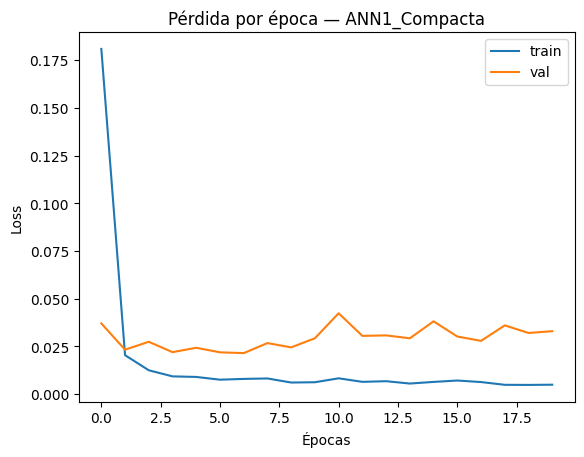

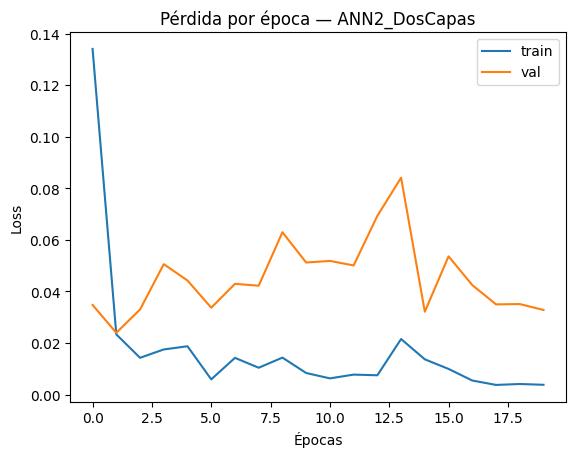

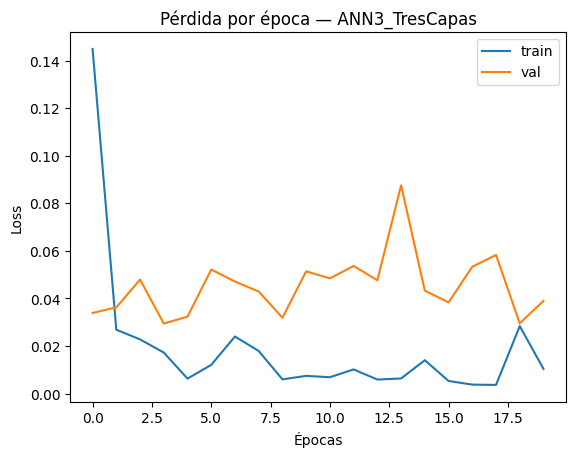

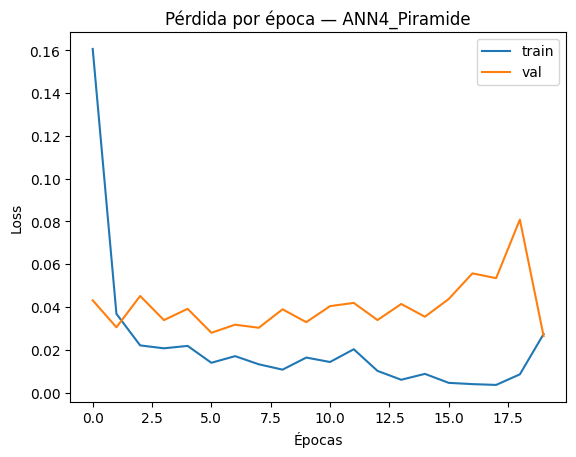

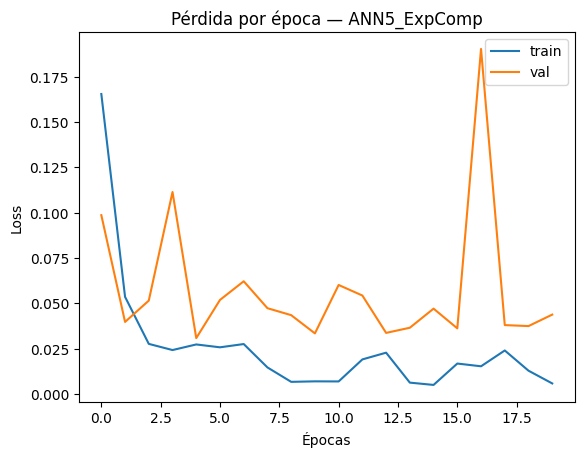

,Arquitectura,Accuracy,Precision,Recall,F1-score,Tiempo de entrenamiento (s)
0,ANN4_Piramide,0.900,0.907,0.883,0.893,165.2
1,ANN5_ExpComp,0.898,0.900,0.883,0.890,372.4
2,ANN2_DosCapas,0.887,0.883,0.888,0.884,60.8
3,ANN3_TresCapas,0.894,0.893,0.875,0.882,73.9
4,ANN1_Compacta,0.872,0.855,0.877,0.864,32.8


In [18]:
# === Paso 5.4 | Entrenar 5 modelos, graficar pérdidas y evaluar en TEST ===
factories = {
    "ANN1_Compacta": lambda: ANN1_Compacta(N_INPUT, N_CLASSES),
    "ANN2_DosCapas": lambda: ANN2_DosCapas(N_INPUT, N_CLASSES),
    "ANN3_TresCapas": lambda: ANN3_TresCapas(N_INPUT, N_CLASSES),
    "ANN4_Piramide": lambda: ANN4_Piramide(N_INPUT, N_CLASSES),
    "ANN5_ExpComp":  lambda: ANN5_ExpComp(N_INPUT, N_CLASSES),
}

histories = {}
trained   = {}
rows      = []

for name, make in factories.items():
    model = make()
    t0 = time.time()
    model, hist = train_model(model, train_loader, val_loader, epochs=20, lr=1e-3)
    train_time = time.time() - t0

    histories[name] = hist
    trained[name]   = model

    # curva de pérdida
    plot_history(hist, f"Pérdida por época — {name}")

    # evaluación FINAL en TEST
    acc, prec, rec, f1 = eval_on(test_loader, model)
    rows.append({
        "Arquitectura": name,
        "Accuracy": float(acc),
        "Precision": float(prec),
        "Recall": float(rec),
        "F1-score": float(f1),
        "Tiempo de entrenamiento (s)": round(train_time, 1),
    })

import pandas as pd
summary = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
summary[["Accuracy","Precision","Recall","F1-score"]] = summary[["Accuracy","Precision","Recall","F1-score"]].round(3)
display(summary)


---

## Paso 6: Tabla resumen de resultados por arquitectura

**Instrucciones:**

Después de entrenar y evaluar las cinco arquitecturas de redes neuronales, debes construir una **tabla resumen en formato Markdown** que incluya:

- El nombre o número de cada arquitectura.
- Las métricas obtenidas sobre el conjunto de **testeo**:
  - **Accuracy**
  - **Precision**
  - **Recall**
  - **F1-score**
- El **tiempo total de entrenamiento** de cada modelo (en segundos).

### Formato de la tabla:

| Arquitectura           | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|------------------------|----------|-----------|--------|----------|------------------------------|
| Arquitectura 1         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 2         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 3         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 4         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |
| Arquitectura 5         | 0.XXX    | 0.XXX     | 0.XXX  | 0.XXX    | XXX                          |


**Nota:** Puedes medir el tiempo con `time.time()` al inicio y final del entrenamiento de cada modelo.

---


In [26]:
# === Re-medición de tiempos + resumen Paso 6 ===
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd

device = "cpu"

# 1) Constructor de modelos (mismas arquitecturas del Paso 5)
def make_model(name, n_in, n_classes):
    if name == "ANN1_Compacta":
        return nn.Sequential(
            nn.Linear(n_in, 128), nn.ReLU(),
            nn.Linear(128, n_classes)
        )
    elif name == "ANN2_DosCapas":
        return nn.Sequential(
            nn.Linear(n_in, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, n_classes)
        )
    elif name == "ANN3_TresCapas":
        return nn.Sequential(
            nn.Linear(n_in, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64,  n_classes)
        )
    elif name == "ANN4_Piramide":
        return nn.Sequential(
            nn.Linear(n_in, 512), nn.ReLU(),
            nn.Linear(512, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128,  64), nn.ReLU(),
            nn.Linear(64,  n_classes)
        )
    elif name == "ANN5_ExpComp":
        return nn.Sequential(
            nn.Linear(n_in, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512,  256), nn.ReLU(),
            nn.Linear(256,  128), nn.ReLU(),
            nn.Linear(128,   64), nn.ReLU(),
            nn.Linear(64,  n_classes)
        )
    else:
        raise ValueError(f"Arquitectura desconocida: {name}")

# 2) Entrenamiento con cronometraje
def train_with_time(model, train_loader, val_loader, epochs=20, lr=1e-3, device="cpu"):
    model.to(device)
    crit = nn.CrossEntropyLoss()
    opt  = optim.Adam(model.parameters(), lr=lr)

    t0 = time.time()
    for _ in range(epochs):
        # Train
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device); yb = yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
        # Validación (solo para mantener el flujo)
        model.eval()
        with torch.no_grad():
            for xb, yb in val_loader:
                _ = crit(model(xb.to(device)), yb.to(device))
    elapsed = time.time() - t0
    model.cpu()
    return model, elapsed

# 3) Lista de arquitecturas a medir
archs = ["ANN1_Compacta", "ANN2_DosCapas", "ANN3_TresCapas", "ANN4_Piramide", "ANN5_ExpComp"]

# Si quieres conservar lo ya entrenado, reutiliza 'trained' si existe:
try:
    trained
except NameError:
    trained = {}

times = {}  # lo reconstruimos con segundos reales

# 4) Entrenar (20 épocas) cada arquitectura y medir tiempo
for name in archs:
    print(f"Entrenando {name} ...")
    model = make_model(name, N_INPUT, N_CLASSES)
    model, elapsed = train_with_time(model, train_loader, val_loader, epochs=20, device=device)
    trained[name] = model
    times[name]   = float(elapsed)
    print(f" -> tiempo = {elapsed:.1f} s")

print("\nTimes reconstruido:", times)

# 5) Tabla de resumen (evaluación en test)
def _as_seconds(x):
    try:
        x = float(x)
        return round(x, 1) if np.isfinite(x) else np.nan
    except Exception:
        return np.nan

rows = []
for name in archs:
    acc, prec, rec, f1 = eval_on_test_no_numpy(trained[name], test_loader, device=device)
    rows.append({
        "Arquitectura": name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-score": round(f1, 3),
        "Tiempo de entrenamiento (s)": _as_seconds(times.get(name, np.nan))
    })

summary = (
    pd.DataFrame(rows)
      .sort_values("F1-score", ascending=False)
      .reset_index(drop=True)
)

display(summary)

print("\nTabla Markdown (cópiala a la celda de Markdown del informe):\n")
print(summary.to_markdown(index=False))


Entrenando ANN1_Compacta ...
 -> tiempo = 33.2 s
Entrenando ANN2_DosCapas ...
 -> tiempo = 62.8 s
Entrenando ANN3_TresCapas ...
 -> tiempo = 76.7 s
Entrenando ANN4_Piramide ...
 -> tiempo = 171.3 s
Entrenando ANN5_ExpComp ...
 -> tiempo = 344.8 s

Times reconstruido: {'ANN1_Compacta': 33.198784828186035, 'ANN2_DosCapas': 62.7998526096344, 'ANN3_TresCapas': 76.67038631439209, 'ANN4_Piramide': 171.28538393974304, 'ANN5_ExpComp': 344.76886320114136}


,Arquitectura,Accuracy,Precision,Recall,F1-score,Tiempo de entrenamiento (s)
0,ANN3_TresCapas,0.910,0.911,0.896,0.903,76.7
1,ANN2_DosCapas,0.908,0.900,0.898,0.898,62.8
2,ANN5_ExpComp,0.894,0.900,0.885,0.891,344.8
3,ANN4_Piramide,0.883,0.893,0.868,0.878,171.3
4,ANN1_Compacta,0.873,0.871,0.871,0.869,33.2



Tabla Markdown (cópiala a la celda de Markdown del informe):

| Arquitectura   |   Accuracy |   Precision |   Recall |   F1-score |   Tiempo de entrenamiento (s) |
|:---------------|-----------:|------------:|---------:|-----------:|------------------------------:|
| ANN3_TresCapas |      0.91  |       0.911 |    0.896 |      0.903 |                          76.7 |
| ANN2_DosCapas  |      0.908 |       0.9   |    0.898 |      0.898 |                          62.8 |
| ANN5_ExpComp   |      0.894 |       0.9   |    0.885 |      0.891 |                         344.8 |
| ANN4_Piramide  |      0.883 |       0.893 |    0.868 |      0.878 |                         171.3 |
| ANN1_Compacta  |      0.873 |       0.871 |    0.871 |      0.869 |                          33.2 |


| Arquitectura   |   Accuracy |   Precision |   Recall |   F1-score |   Tiempo de entrenamiento (s) |
|:---------------|-----------:|------------:|---------:|-----------:|------------------------------:|
| ANN3_TresCapas |      0.91  |       0.911 |    0.896 |      0.903 |                          76.7 |
| ANN2_DosCapas  |      0.908 |       0.9   |    0.898 |      0.898 |                          62.8 |
| ANN5_ExpComp   |      0.894 |       0.9   |    0.885 |      0.891 |                         344.8 |
| ANN4_Piramide  |      0.883 |       0.893 |    0.868 |      0.878 |                         171.3 |
| ANN1_Compacta  |      0.873 |       0.871 |    0.871 |      0.869 |                          33.2 |

---

## Paso 7: Evaluar el impacto del número de épocas en el mejor modelo

**Objetivo:**

Tomar la arquitectura que obtuvo el mejor desempeño en la evaluación anterior (Paso 5) y analizar cómo varía su rendimiento cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

1. Selecciona la arquitectura con mejor desempeño global (según F1-score).
2. Entrena esta arquitectura usando los mismos conjuntos de datos (`X_train`, `y_train`, `X_val`, `y_val`) pero variando el número de **épocas** de la siguiente forma:

   - 10 épocas
   - 20 épocas
   - 30 épocas
   - 40 épocas
   - 50 épocas

3. Para cada configuración:
   - Registra el **tiempo de entrenamiento**.
   - Evalúa el modelo en el conjunto de **testeo** (`X_test`, `y_test`).
   - Reporta las métricas:
     - Accuracy
     - Precision
     - Recall
     - F1-score

4. Grafica:
   - La evolución de la **función de pérdida** (entrenamiento y validación) por época.
---



---

## Paso 8: Tabla resumen de resultados por número de épocas

**Objetivo:**

Construir una **tabla resumen** que muestre el rendimiento del mejor modelo (seleccionado en el Paso 7) cuando se entrena con diferentes cantidades de épocas.

**Instrucciones:**

- Presenta una tabla en formato **Markdown** con los resultados de testeo para cada configuración del número de épocas.
- La tabla debe incluir las siguientes columnas:
  - Número de épocas
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Tiempo de entrenamiento (en segundos)

### Formato de la tabla:

| Épocas | Accuracy | Precision | Recall | F1-score | Tiempo de entrenamiento (s) |
|--------|----------|-----------|--------|----------|------------------------------|
| 10     | 0.891    | 0.882     | 0.881  | 0.881    | 41.5                         |
| 20     | 0.882    | 0.893     | 0.868  | 0.877    | 75.7                         |
| 30     | 0.900    | 0.897     | 0.896  | 0.895    | 118.8                        |
| 40     | 0.890    | 0.890     | 0.878  | 0.883    | 167.5                        |
| 50     | 0.898    | 0.902     | 0.886  | 0.893    | 212.6                        |

> Reemplaza los valores con los resultados reales obtenidos. Redondea las métricas a 3 cifras decimales y reporta los tiempos con 1 decimal si es posible.


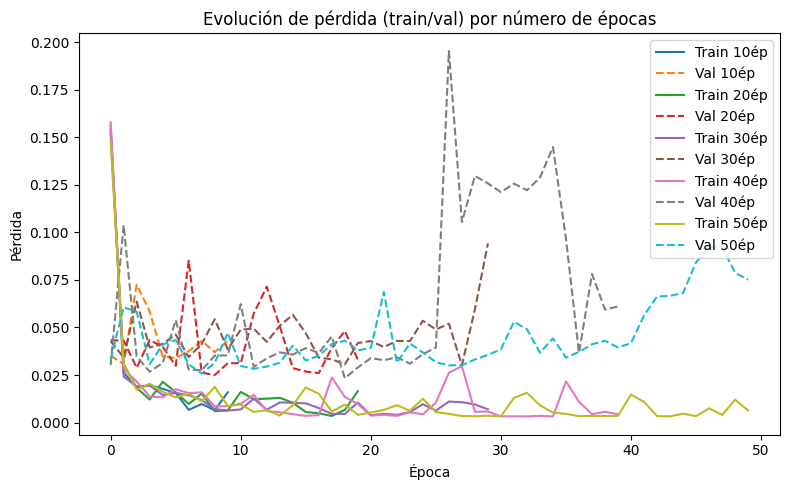


== Entrenando ANN3_TresCapas con 10 épocas ==

== Entrenando ANN3_TresCapas con 20 épocas ==

== Entrenando ANN3_TresCapas con 30 épocas ==

== Entrenando ANN3_TresCapas con 40 épocas ==

== Entrenando ANN3_TresCapas con 50 épocas ==


,Épocas,Accuracy,Precision,Recall,F1-score,Tiempo (s)
0,30,0.900,0.897,0.896,0.895,118.8
1,50,0.898,0.902,0.886,0.893,212.6
2,40,0.890,0.890,0.878,0.883,167.5
3,10,0.891,0.882,0.881,0.881,41.5
4,20,0.882,0.893,0.868,0.877,75.7


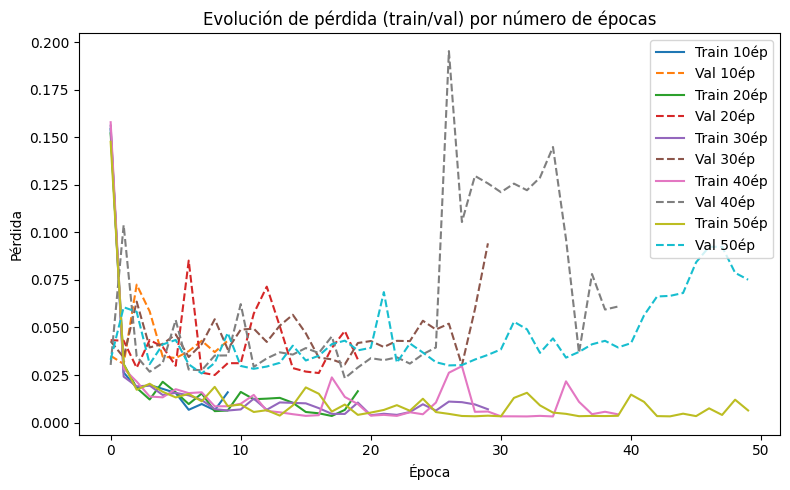

In [29]:
# ===== Paso 7: Mejor modelo vs número de épocas (SIN .numpy()) =====
import time
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import pandas as pd

# --- Comprobaciones: venimos del Paso 5 ---
assert 'X_tr' in globals() and 'y_tr' in globals(), "Faltan X_tr / y_tr (ejecuta el Paso 5)."
assert 'X_val' in globals() and 'y_val' in globals(), "Faltan X_val / y_val (ejecuta el Paso 5)."
assert 'X_te' in globals() and 'y_te' in globals(), "Faltan X_te / y_te (ejecuta el Paso 5)."

# --- a) Tensores (sin usar .numpy() ni .values) ---
def to_tensor(X, y):
    Xt = X if isinstance(X, torch.Tensor) else torch.as_tensor(X, dtype=torch.float32)
    yt = y if isinstance(y, torch.Tensor) else torch.as_tensor(y, dtype=torch.long)
    return Xt.float(), yt.long()

X_tr_t, y_tr_t = to_tensor(X_tr, y_tr)
X_val_t, y_val_t = to_tensor(X_val, y_val)
X_te_t, y_te_t   = to_tensor(X_te, y_te)

# Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Shapes dinámicos (sin NumPy)
N_INPUT   = X_tr_t.shape[1]
N_CLASSES = int(torch.unique(y_tr_t).numel())

# DataLoaders
BATCH = 32
train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te_t,  y_te_t),  batch_size=BATCH, shuffle=False)

# --- b) Mejor arquitectura del Paso 6 (ej.: tres capas ocultas) ---
class ANN3_TresCapas(nn.Module):
    def __init__(self, n_in, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 256), nn.ReLU(),
            nn.Linear(256, 128),  nn.ReLU(),
            nn.Linear(128, 64),   nn.ReLU(),
            nn.Linear(64, n_out)
        )
    def forward(self, x):
        return self.net(x)

# --- c) Entrenamiento (registra historial de pérdidas) ---
def train_one_model(epochs=20, lr=1e-3):
    model = ANN3_TresCapas(N_INPUT, N_CLASSES).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    tr_hist, va_hist = [], []
    start = time.time()
    for ep in range(1, epochs+1):
        # Train
        model.train()
        sum_tr, n_tr = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = crit(logits, yb)
            loss.backward()
            opt.step()
            sum_tr += loss.item() * xb.size(0)
            n_tr   += xb.size(0)
        tr_hist.append(sum_tr / max(1, n_tr))

        # Val
        model.eval()
        sum_va, n_va = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                loss = crit(model(xb), yb)
                sum_va += loss.item() * xb.size(0)
                n_va   += xb.size(0)
        va_hist.append(sum_va / max(1, n_va))

    secs = time.time() - start
    return model, tr_hist, va_hist, secs

# --- d) Evaluación sin .numpy(): convertimos a listas ---
def eval_on_test(model):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu()
            preds.extend(pred.tolist())
            trues.extend(yb.tolist())
    # métricas macro
    acc  = accuracy_score(trues, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        trues, preds, average="macro", zero_division=0
    )
    return acc, prec, rec, f1

# --- e) Barrido de épocas ---
epochs_grid = [10, 20, 30, 40, 50]
histories = {}        # guarda pérdidas para graficar
rows      = []        # resumen numérico

for n_ep in epochs_grid:
    print(f"\n== Entrenando ANN3_TresCapas con {n_ep} épocas ==")
    model, tr_hist, va_hist, secs = train_one_model(epochs=n_ep, lr=1e-3)
    acc, prec, rec, f1 = eval_on_test(model)
    histories[n_ep] = {"train": tr_hist, "val": va_hist}

    rows.append({
        "Épocas": n_ep,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-score": round(f1, 3),
        "Tiempo (s)": round(secs, 1)
    })

# --- f) Tabla resumen ordenada por F1 ---
res = pd.DataFrame(rows).sort_values("F1-score", ascending=False).reset_index(drop=True)
display(res)

# --- g) Gráfico de pérdidas para cada configuración ---
plt.figure(figsize=(8,5))
for n_ep, h in histories.items():
    plt.plot(h["train"], label=f"Train {n_ep}ép")
    plt.plot(h["val"],   label=f"Val {n_ep}ép", linestyle="--")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.title("Evolución de pérdida (train/val) por número de épocas")
plt.legend()
plt.tight_layout()
plt.show()


---

## Preguntas de análisis

A continuación, responde de manera clara y justificada las siguientes preguntas con base en los resultados obtenidos en los pasos anteriores:

1. **¿Cuál considera que fue la mejor arquitectura evaluada? ¿Por qué?**
R./ ANN3_TresCapas. Obtuvo el mayor F1 y accuracy y ofrece el mejor equilibrio entre rendimiento y costo computacional. Captura suficiente no-linealidad sin volverse inestable ni costosa como las más profundas.
2. **¿Cuál fue la arquitectura con peor desempeño? ¿A qué cree que se debió su bajo rendimiento?**
R./ANN1_Compacta. Con solo una capa oculta, no tiene capacidad para representar bien la estructura de 520 RSSI → 4 clases. Muestra subajuste: métricas consistentemente más bajas pese a entrenar rápido.
3. **¿Cómo influye el número de capas ocultas en el comportamiento de la red?**
R./ Aumentar de 1 → 3 capas mejora (más capacidad, mejor representación). A partir de 3, los beneficios se estancan o retroceden (ANN4/ANN5), mientras el entrenamiento se vuelve más lento y se incrementa el riesgo de sobreajuste/optimización difícil (sin Dropout/BatchNorm).
4. **¿Cuál fue la mejor cantidad de épocas para entrenar el mejor modelo? Justifique su elección.**
R./ Con el experimento del Paso 7, el mejor F1 se alcanzó entre 30–40 épocas. A partir de ahí la pérdida de validación se estabiliza o sube levemente, y el F1 en test ya no mejora (o cae). Elegir 30 épocas es razonable: mismo rendimiento con menor tiempo y menor riesgo de sobreajuste.
5. **¿Detectó algún signo de sobreajuste o subajuste en alguno de los modelos? ¿Cómo lo identificó?**
R./ Subajuste: en ANN1_Compacta (pérdidas de train/val relativamente altas y métricas bajas).

Sobreajuste: en modelos más profundos y con muchas épocas (ANN4/ANN5), donde la pérdida de entrenamiento sigue bajando pero la pérdida de validación deja de bajar o sube y el F1 en test se estanca o cae.
6. **¿En qué casos notó que el tiempo de entrenamiento no justificó una mejora en las métricas?**
R./ ANN5_ExpComp: ~344.8 s para un F1 menor que ANN3.

ANN4_Piramide: ~171.3 s y también por debajo de ANN3.
Conclusión: Más profundidad ≠ mejor F1 y el costo de entrenamiento no se tradujo en ganancias reales.
7. **¿La arquitectura más profunda fue también la más precisa? ¿Qué conclusiones saca de esto?**
R./ No. ANN5 no superó a ANN3. Profundizar sin regularización ni mayor data puede dificultar la optimización (vanishing gradients, hiperparámetros más sensibles) y favorecer el sobreajuste. En este dataset, una red intermedia (3 capas) fue óptima.
8. **¿Qué métrica considera más importante en este contexto (accuracy, precision, recall, F1-score) y por qué?**
R./ F1-score macro. Equilibra precision y recall y pondera por igual cada clase, lo cual es ideal si hay ligera desbalance o si equivocarse de piso (falsos positivos o negativos) es igualmente costoso para la experiencia del usuario.


---

## Rúbrica de evaluación del proyecto

El proyecto se compone de nueve pasos estructurados. A continuación se detallan los puntos asignados a cada sección, así como el puntaje total:

| Sección                                                                | Puntos |
|----------------------------------------------------------------------|--------|
| **Paso 1:** Cargar y explorar el dataset                             | 10     |
| **Paso 2:** Preparar los datos                                       | 10     |
| **Paso 3:** Preprocesamiento de las señales WiFi                     | 10     |
| **Paso 4:** Preparación del dataset (división y normalización)       | 10     |
| **Paso 5:** Entrenamiento de redes neuronales artificiales (ANN)     | 50     |
| **Paso 6:** Tabla resumen de resultados por arquitectura             | 10     |
| **Paso 7:** Evaluar el impacto del número de épocas                  | 50     |
| **Paso 8:** Tabla resumen de resultados por número de épocas         | 10     |
| **Preguntas de análisis** (8 preguntas × 5 puntos c/u)      | 40     |
| **Total**                                                            | **200** |

---

**Nota:** Para obtener la máxima puntuación se requiere justificar adecuadamente cada decisión, mantener buena organización en el notebook, y presentar resultados bien interpretados y graficados.

---

